In [2]:
import numpy as np

In [3]:
import mcstasscript as ms


In [4]:
pip install pytest


Note: you may need to restart the kernel to use updated packages.


In [5]:
configurator = ms.Configurator()
configurator.set_mcrun_path("/usr/bin/")
configurator.set_mcstas_path("/usr/share/mcstas/resources/")
print(configurator)

Configurator:
 paths:
  mcrun_path: /usr/bin/
  mcstas_path: /usr/share/mcstas/resources/
  mcxtrace_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/
  mxrun_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/bin/
 other:
  characters_per_line: 85



In [6]:
pip install pytest

Note: you may need to restart the kernel to use updated packages.


In [7]:
instrument = ms.McStas_instr("NSM_instrument")

In [8]:
instrument.available_components()

Here are the available component categories:
 contrib
 misc
 monitors
 obsolete
 optics
 samples
 sasmodels
 sources
 union
Call available_components(category_name) to display


In [9]:
instrument.available_components("monitors")

Here are all components in the monitors category.
 Brilliance_monitor     MeanPolLambda_monitor   PolLambda_monitor
 Cyl_monitor            Monitor                 Pol_monitor
 Cyl_monitor_PSD        Monitor_4PI             Res_monitor
 Cyl_monitor_TOF        Monitor_nD              Sqq_w_monitor
 Div1D_monitor          Monitor_nD_noacc        Sqw_monitor
 DivLambda_monitor      PSD_TOF_monitor         TOF2E_monitor
 DivPos_monitor         PSD_monitor             TOF2Q_cylPSD_monitor
 Divergence_monitor     PSD_monitor_4PI         TOFLambda_monitor
 EPSD_monitor           PSD_monitor_4PI_spin    TOFRes_monitor
 E_monitor              PSD_monitor_TOF         TOF_PSD_monitor_rad
 Event_monitor_simple   PSD_monitor_psf         TOF_cylPSD_monitor
 Flex_monitor_1D        PSD_monitor_psf_eff     TOF_monitor
 Flex_monitor_2D        PSDcyl_monitor          TOFlog_monitor
 Flex_monitor_3D        PSDlin_diff_monitor     
 L_monitor              PSDlin_monitor          


In [10]:
instrument.available_components("sources")

Here are all components in the sources category.
 Adapt_check     Monitor_Optimizer   Source_adapt       Source_simple
 ESS_butterfly   Source_4PI          Source_div         
 ESS_moderator   Source_Maxwell_3    Source_div_quasi   
 Moderator       Source_Optimizer    Source_gen         


##  Primary beam / monochromatic optics

In [11]:
prim_shut_pos = instrument.add_parameter("int", "prim_shut_pos", value=1,
                    comment="1, 2, or 3 primary shutter opening")
sapphire = instrument.add_parameter("int", "sapphire", value=1,
                    comment="sapphire filter 1 = in, else out")
ca1 = instrument.add_parameter("int", "ca1", value=80, comment="alpha 1 collimation 20,40,60, 80 = open")
ca2 = instrument.add_parameter("int", "ca2", value=80, comment="alpha 2 collimation 15,40,60, 80 = open")
ca3 = instrument.add_parameter("int", "ca3", value=80, comment="alpha 3 collimation 15,40,60, 80 = open")
ca4 = instrument.add_parameter("int", "ca4", value=80, comment="alpha 4 collimation 15,40,60, 80 = open")
ms1 = instrument.add_parameter("ms1", value=0.04, comment="width of virtual source")

##  Geometry (arm lengths)

In [12]:
lms = instrument.add_parameter("lms", value=2.10, comment="distance mono to sample", dimension="m")
lsa = instrument.add_parameter("lsa", value=1.05, comment="distance sample to ana", dimension="m")
lad = instrument.add_parameter("lad", value=0.95, comment="distance ana to detector", dimension="m")

##  Physics setpoint

In [13]:
ki = instrument.add_parameter("ki", value=0, comment="incident wavevector, if 0 not used")
kf = instrument.add_parameter("kf", value=0, comment="final wavevector, if 0 not used")
dE = instrument.add_parameter("dE", value=0, comment="energy transfer (meV)")
Q  = instrument.add_parameter("Q",  value=0, comment="momentum transfer in (AA-1)")
scatsense_mono   = instrument.add_parameter("int", "scatsense_mono",   value=-1, comment="scattering sense at mono")
scatsense_sample = instrument.add_parameter("int", "scatsense_sample", value=1,  comment="scattering sense at sample")
scatsense_ana    = instrument.add_parameter("int", "scatsense_ana",    value=-1, comment="scattering sense at ana")

##  Monochromator axis

In [14]:
mth = instrument.add_parameter("mth", value=0,   comment="theta monochromator")
mtt = instrument.add_parameter("mtt", value=0,   comment="2theta monochromator")
mtx = instrument.add_parameter("mtx", value=0,   comment="x translation monochromator")
mty = instrument.add_parameter("mty", value=0,   comment="y translation monochromator")
mgy = instrument.add_parameter("mgy", value=0,   comment="gonio monochromator")
mfh = instrument.add_parameter("mfh", value=4.5, comment="horizontal focus monochromator")
mfv = instrument.add_parameter("mfv", value=2,   comment="vertical focus monochromator")

## Sample table

In [15]:

sth = instrument.add_parameter("sth", value=0, comment="theta sample")
stt = instrument.add_parameter("stt", value=0, comment="2theta sample")
stx = instrument.add_parameter("stx", value=0, comment="x trans sample")
sty = instrument.add_parameter("sty", value=0, comment="y trans sample")
stz = instrument.add_parameter("stz", value=0, comment="z trans sample")
sgx = instrument.add_parameter("sgx", value=0, comment="x gonio sample")
sgy = instrument.add_parameter("sgy", value=0, comment="y gonio sample")
ss1_width  = instrument.add_parameter("ss1_width",  value=0.02, comment="ss1 width")
ss1_height = instrument.add_parameter("ss1_height", value=0.03, comment="ss1 height")
ss2_width  = instrument.add_parameter("ss2_width",  value=0.02, comment="ss2 width")
ss2_height = instrument.add_parameter("ss2_height", value=0.04, comment="ss2 height")

## Analyser table

In [16]:

 
ath = instrument.add_parameter("ath", value=0,   comment="theta analyser")
att = instrument.add_parameter("att", value=0,   comment="2theta analyser")
atx = instrument.add_parameter("atx", value=0,   comment="x trans analyser")
aty = instrument.add_parameter("aty", value=0,   comment="y trans analyser")
agy = instrument.add_parameter("agy", value=0,   comment="y gonio analyser")
afh = instrument.add_parameter("afh", value=1.7, comment="horizontal focus analyser")
afv = instrument.add_parameter("afv", value=0.6, comment="vertical focus analyser")
 

# Initialize section

The `INITIALIZE` section runs once when the simulation starts, allowing calculations to be performed before the ray-tracing begins. For this instrument, it computes `ki`, `kf`, `dE`, `sth`, and `stt`, depending on which parameters are supplied.

In [17]:
# Divergence variables filled in during INITIALIZE
ca1_div = instrument.add_declare_var("double", "ca1_div")
ca2_div = instrument.add_declare_var("double", "ca2_div")
ca3_div = instrument.add_declare_var("double", "ca3_div")
ca4_div = instrument.add_declare_var("double", "ca4_div")

instrument.append_initialize("""
switch(ca1)
{
    case 20 : ca1_div = 20; break;
    case 40 : ca1_div = 40; break;
    case 60 : ca1_div = 60; break;
    default : ca1_div = 120;
}

switch(ca2)
{
    case 15 : ca2_div = 15; break;
    case 40 : ca2_div = 40; break;
    case 60 : ca2_div = 60; break;
    default : ca2_div = 120;
}

switch(ca3)
{
    case 15 : ca3_div = 15; break;
    case 40 : ca3_div = 40; break;
    case 60 : ca3_div = 60; break;
    default : ca3_div = 120;
}

switch(ca4)
{
    case 15 : ca4_div = 15; break;
    case 40 : ca4_div = 40; break;
    case 60 : ca4_div = 60; break;
    default : ca4_div = 120;
}
""")

In [18]:
a1 = instrument.add_declare_var("double", "a1")
a2 = instrument.add_declare_var("double", "a2")
a3 = instrument.add_declare_var("double", "a3")
a4 = instrument.add_declare_var("double", "a4")
a5 = instrument.add_declare_var("double", "a5")
a6 = instrument.add_declare_var("double", "a6")
my_ki = instrument.add_declare_var("double", "my_ki")
my_kf = instrument.add_declare_var("double", "my_kf")
my_thetas= instrument.add_declare_var("double", "my_thetas")
Lam= instrument.add_declare_var("double", "Lam")
dLam= instrument.add_declare_var("double", "dLam")
MINLam= instrument.add_declare_var("double", "MINLam")
MAXLam= instrument.add_declare_var("double", "MAXLam")
d_PG002 = instrument.add_declare_var("double", "d_PG002", value=3.355, comment="PG(002) d-spacing [AA]")

In [19]:
instrument.append_initialize("""
a1 = mth; a2 = mtt; a3 = 0; a4 = 0; a5 = ath; a6 = att;

if (kf) {
    my_kf = kf;
    if (dE) { my_ki = sqrt(dE / 2.072 + kf*kf); }   
    else    { my_ki = kf; }
    Lam  = 2*PI/my_ki;
    dLam = 0.03 * Lam;
}
else if (ki) {
    my_ki = ki;
    if (dE) { my_kf = sqrt(ki*ki - dE / 2.072); }  
    else    { my_kf = ki; }                        
    Lam  = 2*PI/my_ki;
    dLam = 0.03 * Lam;
}
else {
    my_ki = PI / d_PG002 / sin(fabs(mtt) / 2 * DEG2RAD);
    my_kf = PI / d_PG002 / sin(fabs(att) / 2 * DEG2RAD);
    dE   = 81.82 / ((2*PI/(my_kf-my_ki)) * (2*PI/(my_kf-my_ki)));
    Lam  = 2*PI/my_ki;
    dLam = 0.03 * Lam;
}

if ((Q) && (my_ki) && (my_kf)) { 
    my_thetas = acos( (my_ki*my_ki + my_kf*my_kf - Q*Q) / 2 / my_ki / my_kf );
    a4 = my_thetas*RAD2DEG;
}
else { a4 = stt; }

a3 = sth;

if (kf || ki) {
    a1 = -asin( PI/d_PG002/my_ki )*RAD2DEG;
    a2 = 2*a1;
    a5 = -asin( PI/d_PG002/my_kf )*RAD2DEG;
    a6 = 2*a5;
}

MINLam = Lam - dLam;
MAXLam = Lam + dLam;

printf("ki: %f A-1\\n", my_ki);
printf("kf: %f A-1\\n", my_kf);
printf("dE: %f meV\\n", dE);
printf("Lam: %f A\\n", Lam);
printf("dLam: %f A\\n", dLam);
printf("mth: %f deg\\n", a1);
printf("mtt: %f deg\\n", a2);
printf("sth: %f deg\\n", a3);
printf("stt: %f deg\\n", a4);
printf("ath: %f deg\\n", a5);
printf("att: %f deg\\n", a6);
""")

In [20]:
print(instrument.initialize_section)

// Start of initialize for generated NSM_instrument

switch(ca1)
{
    case 20 : ca1_div = 20; break;
    case 40 : ca1_div = 40; break;
    case 60 : ca1_div = 60; break;
    default : ca1_div = 120;
}

switch(ca2)
{
    case 15 : ca2_div = 15; break;
    case 40 : ca2_div = 40; break;
    case 60 : ca2_div = 60; break;
    default : ca2_div = 120;
}

switch(ca3)
{
    case 15 : ca3_div = 15; break;
    case 40 : ca3_div = 40; break;
    case 60 : ca3_div = 60; break;
    default : ca3_div = 120;
}

switch(ca4)
{
    case 15 : ca4_div = 15; break;
    case 40 : ca4_div = 40; break;
    case 60 : ca4_div = 60; break;
    default : ca4_div = 120;
}


a1 = mth; a2 = mtt; a3 = 0; a4 = 0; a5 = ath; a6 = att;

if (kf) {
    my_kf = kf;
    if (dE) { my_ki = sqrt(dE / 2.072 + kf*kf); }   
    else    { my_ki = kf; }
    Lam  = 2*PI/my_ki;
    dLam = 0.03 * Lam;
}
else if (ki) {
    my_ki = ki;
    if (dE) { my_kf = sqrt(ki*ki - dE / 2.072); }  
    else    { my_kf = ki; }                    

In [21]:
origin=instrument.add_component("origin", "Progress_bar")
origin.set_AT([0, 0, 0.0])


In [22]:
source = instrument.add_component("source", "Source_gen")
source.show_parameters()

 ___ Help Source_gen ________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
flux_file = "NULL" [str] // Name of a two columns [lambda flux] text file that 
                            contains the wavelength distribution of the flux in 
                            <b>either</b> [1/(s*cm**2*st)] <b>or</b> 
                            [1/(s*cm**2*st*AA)] (see flux_file_perAA flag) Comments 
                            (#) and further columns are ignored. Format is 
                            compatible with McStas/PGPLOT wavelength monitor files. 
                            When specified, temperature and intensity values are 
                            ignored. 
xdiv_file = "NULL" [str] // Name of the x-horiz. divergence distribution file, 
                            given as a free format text matrix, preceeded with a 
                            line '# xylimits 
ydiv_file = "NULL" [str] // Name o

In [23]:
source.lambda0 = Lam
print(source)

COMPONENT source = Source_gen(
  lambda0 = Lam // [AA]
)
AT (0, 0, 0) ABSOLUTE


In [24]:
source.dlambda = dLam
print(source)

COMPONENT source = Source_gen(
  lambda0 = Lam, // [AA]
  dlambda = dLam // [AA]
)
AT (0, 0, 0) ABSOLUTE


In [25]:
source.xwidth = 0.135
source.yheight = 0.08
source.dist = 0.79045+0.39063
source.T1 = 361.9
source.I1 = 7.22e12 
source.T2 = 159.0
source.I2 = 6.74e12
source.T3 = 35.66
source.I3 = 6.435e12
source.focus_xw = 0.11
source.focus_yh = 0.1
print(source)

COMPONENT source = Source_gen(
  dist = 1.18108, // [m]
  focus_xw = 0.11, // [m]
  focus_yh = 0.1, // [m]
  lambda0 = Lam, // [AA]
  dlambda = dLam, // [AA]
  I1 = 7220000000000.0, // [1/(cm**2*sr)]
  yheight = 0.08, // [m]
  xwidth = 0.135, // [m]
  T1 = 361.9, // [K]
  T2 = 159.0, // [K]
  I2 = 6740000000000.0, // [1/(cm**2*sr)]
  T3 = 35.66, // [K]
  I3 = 6435000000000.0 // [1/(cm**2*sr)]
)
AT (0, 0, 0) ABSOLUTE


In [26]:
DIV= instrument.add_component("DIV", "Divergence_monitor")

In [27]:
DIV.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                   maxdiv_h= 4, maxdiv_v=5, nh =40, nv =40, restore_neutron=1)
DIV.set_AT([0, 0, 0.0001], RELATIVE=source)
print(DIV)

COMPONENT DIV = Divergence_monitor(
  nh = 40, // [1]
  nv = 40, // [1]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.15, // [m]
  ymax = 0.15, // [m]
  maxdiv_h = 4, // [degrees]
  maxdiv_v = 5, // [degrees]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.0001) RELATIVE source


In [28]:

PSD_1 = instrument.add_component("PSD_1", "PSD_monitor")
PSD_1.show_parameters()
PSD_1.set_AT([0, 0, 0.01], RELATIVE=source)

 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [29]:
PSD_1.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.10, ymax=0.10,nx=80,ny=200, filename='"PSD_1.dat"', restore_neutron=1)
print(PSD_1)

COMPONENT PSD_1 = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD_1.dat", // [string]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.1, // [m]
  ymax = 0.1, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.01) RELATIVE source


In [30]:
instrument.available_components("optics")

Here are all components in the optics category.
 Absorber                 Guide_channeled        Pol_FieldBox
 Arm                      Guide_gravity          Pol_SF_ideal
 Beamstop                 Guide_simple           Pol_bender
 Bender                   Guide_tapering         Pol_constBfield
 Collimator_linear        Guide_wavy             Pol_guide_mirror
 Collimator_radial        He3_cell               Pol_guide_vmirror
 Derotator                Mask                   Pol_mirror
 Diaphragm                Mirror                 Pol_tabled_field
 DiskChopper              Monochromator_curved   Refractor
 Elliptic_guide_gravity   Monochromator_flat     Rotator
 FZP_simple               Monochromator_pol      Selector
 FermiChopper             Place                  Set_pol
 Filter_gen               PolAnalyser_ideal      Slit
 Guide                    Pol_Bfield             V_selector
 Guide_anyshape           Pol_Bfield_stop        Vitess_ChopperFermi


In [31]:
NL_SR2_1= instrument.add_component("NL_SR2_1", "Guide_gravity")
NL_SR2_1.show_parameters()

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [32]:

NL_SR2_1.w1 = 0.105
NL_SR2_1.h1 = 0.098
NL_SR2_1.w2 = 0.105
NL_SR2_1.h2 = 0.118
NL_SR2_1.R0 = 0.995
NL_SR2_1.Qc = 0.02174
NL_SR2_1.l=1.307
NL_SR2_1.alpha = 4.38
NL_SR2_1.W = 0.0009
NL_SR2_1.nslit = 1
NL_SR2_1.mleft = 1.0
NL_SR2_1.mright = 1.0
NL_SR2_1.mtop = 1.0
NL_SR2_1.mbottom = 1.0

In [33]:
NL_SR2_1.set_AT([0, 0, 1.18108], RELATIVE=source)
print(NL_SR2_1)

COMPONENT NL_SR2_1 = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.098, // [m]
  w2 = 0.105, // [m]
  h2 = 0.118, // [m]
  l = 1.307, // [m]
  R0 = 0.995, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 4.38, // [AA]
  W = 0.0009, // [AA-1]
  nslit = 1, // [1]
  mleft = 1.0, // [1]
  mright = 1.0, // [1]
  mtop = 1.0, // [1]
  mbottom = 1.0 // [1]
)
AT (0, 0, 1.18108) RELATIVE source


In [34]:
NL_SR2_2a= instrument.add_component("NL_SR2_2a", "Guide_gravity")
NL_SR2_2a.show_parameters()

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [35]:

NL_SR2_2a.w1 = 0.105
NL_SR2_2a.h1 = 0.119
NL_SR2_2a.w2 = 0.106
NL_SR2_2a.h2 = 0.134
NL_SR2_2a.R0 = 0.99
NL_SR2_2a.Qc = 0.02174
NL_SR2_2a.l=0.997
NL_SR2_2a.alpha = 3.0
NL_SR2_2a.W = 0.001
NL_SR2_2a.nslit = 1
NL_SR2_2a.mleft = 3.0
NL_SR2_2a.mright = 3.0
NL_SR2_2a.mtop = 0.0
NL_SR2_2a.mbottom = 0.0
NL_SR2_2a.set_WHEN( " prim_shut_pos== 1")
NL_SR2_2a.set_AT([0, 0, 2.540], RELATIVE=source)
print(NL_SR2_2a)

COMPONENT NL_SR2_2a = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.119, // [m]
  w2 = 0.106, // [m]
  h2 = 0.134, // [m]
  l = 0.997, // [m]
  R0 = 0.99, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 3.0, // [AA]
  W = 0.001, // [AA-1]
  nslit = 1, // [1]
  mleft = 3.0, // [1]
  mright = 3.0, // [1]
  mtop = 0.0, // [1]
  mbottom = 0.0 // [1]
) WHEN ( prim_shut_pos== 1)
AT (0, 0, 2.54) RELATIVE source


In [36]:
NL_SR2_2b=instrument.add_component("NL_SR2_2b", "Guide_gravity")

In [37]:

NL_SR2_2b.w1 = 0.050
NL_SR2_2b.h1 = 0.099
NL_SR2_2b.w2 = 0.050
NL_SR2_2b.h2 = 0.107
NL_SR2_2b.R0 = 0.99
NL_SR2_2b.Qc = 0.02174
NL_SR2_2b.l=0.997
NL_SR2_2b.alpha = 3.0
NL_SR2_2b.W = 0.001
NL_SR2_2b.nslit = 1
NL_SR2_2b.mleft = 0.0
NL_SR2_2b.mright = 0.0
NL_SR2_2b.mtop = 0.0
NL_SR2_2b.mbottom = 0.0
NL_SR2_2b.set_WHEN( " prim_shut_pos==2")
NL_SR2_2b.set_AT([0, 0, 2.540], RELATIVE=source)
print(NL_SR2_2b)

COMPONENT NL_SR2_2b = Guide_gravity(
  w1 = 0.05, // [m]
  h1 = 0.099, // [m]
  w2 = 0.05, // [m]
  h2 = 0.107, // [m]
  l = 0.997, // [m]
  R0 = 0.99, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 3.0, // [AA]
  W = 0.001, // [AA-1]
  nslit = 1, // [1]
  mleft = 0.0, // [1]
  mright = 0.0, // [1]
  mtop = 0.0, // [1]
  mbottom = 0.0 // [1]
) WHEN ( prim_shut_pos==2)
AT (0, 0, 2.54) RELATIVE source


In [38]:
NL_SR2_2c=instrument.add_component("NL_SR2_2c", "Guide_gravity")

In [39]:
NL_SR2_2c.w1 = 0.050
NL_SR2_2c.h1 = 0.099
NL_SR2_2c.w2 = 0.050
NL_SR2_2c.h2 = 0.107
NL_SR2_2c.R0 = 0.99
NL_SR2_2c.Qc = 0.02174
NL_SR2_2c.l=0.997
NL_SR2_2c.alpha = 3.0
NL_SR2_2c.W = 0.001
NL_SR2_2c.nslit = 1
NL_SR2_2c.mleft = 0.0
NL_SR2_2c.mright = 0.0
NL_SR2_2c.mtop = 0.0
NL_SR2_2c.mbottom = 0.0
NL_SR2_2c.set_WHEN( " prim_shut_pos==3 ")
NL_SR2_2c.set_AT([0, 0, 2.540], RELATIVE=source)
print(NL_SR2_2c)

COMPONENT NL_SR2_2c = Guide_gravity(
  w1 = 0.05, // [m]
  h1 = 0.099, // [m]
  w2 = 0.05, // [m]
  h2 = 0.107, // [m]
  l = 0.997, // [m]
  R0 = 0.99, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 3.0, // [AA]
  W = 0.001, // [AA-1]
  nslit = 1, // [1]
  mleft = 0.0, // [1]
  mright = 0.0, // [1]
  mtop = 0.0, // [1]
  mbottom = 0.0 // [1]
) WHEN ( prim_shut_pos==3 )
AT (0, 0, 2.54) RELATIVE source


In [40]:
NL_SR2_2_3 = instrument.add_component("NL_SR2_2_3", "Guide_gravity")

In [41]:
NL_SR2_2_3.show_parameters()
NL_SR2_2_3.set_AT([0, 0, 3.546], RELATIVE=source)
NL_SR2_2_3.set_parameters(w1=0.107, h1=0.135,
                          w2=0.107, h2=0.138,
                          l=0.180, R0=0.99,
                          Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=2.0, mright=2.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [42]:
SR2_Beamportwindow= instrument.add_component("SR2_Beamportwindow", "Al_window")


In [43]:
SR2_Beamportwindow.show_parameters()
SR2_Beamportwindow.set_AT([0, 0, 3.81], RELATIVE=source)
SR2_Beamportwindow.set_parameters(thickness=0.003)

 ___ Help Al_window _________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
thickness = 0.001 [m] // Al Window thickness
-------------------------------------------------------------------------------------


In [44]:
SR2_eob= instrument.add_component("SR2_eob", "Arm")

In [45]:
SR2_eob.set_AT([0, 0, 0.031], RELATIVE='SR2_Beamportwindow')

In [46]:
PANDA_ca1= instrument.add_component("PANDA_ca1", "Collimator_linear")

In [47]:
PANDA_ca1.show_parameters()
PANDA_ca1.set_parameters(xwidth=0.108, yheight=0.160, divergence=80, length=0.50, transmission=1)
PANDA_ca1.set_AT([0,0,0.1000], RELATIVE= 'SR2_eob')

 ___ Help Collimator_linear _________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = -0.02 [m] // Lower x bound on slits
xmax = 0.02 [m] // Upper x bound on slits
ymin = -0.05 [m] // Lower y bound on slits
ymax = 0.05 [m] // Upper y bound on slits
xwidth = 0.0 [m] // Width of slits
yheight = 0.0 [m] // Height of slits
length = 0.3 [m] // Distance between input and output slits
divergence = 40.0 [minutes of arc] // Divergence horizontal angle (calculated 
                                      as atan(d/length), where d is the blade 
                                      spacing) 
transmission = 1.0 [1] // Transmission of Soller (0<=t<=1)
divergenceV = 0.0 [minutes of arc] // Divergence vertical angle
-------------------------------------------------------------------------------------


In [48]:
PANDA_sapphire = instrument.add_component("PANDA_sapphire", "Filter_gen")


In [49]:
PANDA_sapphire.set_parameters(filename = '"Al2O3_sapphire.trm"', thickness = 0.86)
PANDA_sapphire.show_parameters()
PANDA_sapphire.set_AT([0,0,0.9000], RELATIVE= 'SR2_eob')

 ___ Help Filter_gen ________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
filename = "Al2O3_sapphire.trm"
options = 0
xmin = -0.05
xmax = 0.05
ymin = -0.05
ymax = 0.05
xwidth = 0.0
yheight = 0.0
thickness = 0.86
scaling = 1.0
verbose = 0.0
-------------------------------------------------------------------------------------


In [50]:
PANDA_sapphire.show_parameters

<bound method Component.show_parameters of COMPONENT PANDA_sapphire = Filter_gen(
  filename = "Al2O3_sapphire.trm",
  thickness = 0.86
)
AT (0, 0, 0.9) RELATIVE SR2_eob>

In [51]:
sk1_in= instrument.add_component("sk1_in", "Slit")

In [52]:
sk1_in.show_parameters()
sk1_in.set_parameters(xwidth=0.11, yheight=0.15)
sk1_in.set_AT([0,0,1.0100], RELATIVE= 'SR2_eob')

 ___ Help Slit ______________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = UNSET [m] // Lower x bound
xmax = UNSET [m] // Upper x bound
ymin = UNSET [m] // Lower y bound
ymax = UNSET [m] // Upper y bound
radius = UNSET [m] // Radius of slit in the z=0 plane, centered at Origin
xwidth = UNSET [m] // Width of slit. Overrides xmin,xmax if they are unset.
yheight = UNSET [m] // Height of slit. Overrides ymin,ymax if they are unset.
-------------------------------------------------------------------------------------


In [53]:
sk1_out= instrument.add_component("sk1_out", "Slit")

In [54]:
sk1_out.show_parameters()
sk1_out.set_parameters(xwidth=0.09, yheight=0.180)
sk1_out.set_AT([0,0,2.0300], RELATIVE= 'SR2_eob')

 ___ Help Slit ______________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = UNSET [m] // Lower x bound
xmax = UNSET [m] // Upper x bound
ymin = UNSET [m] // Lower y bound
ymax = UNSET [m] // Upper y bound
radius = UNSET [m] // Radius of slit in the z=0 plane, centered at Origin
xwidth = UNSET [m] // Width of slit. Overrides xmin,xmax if they are unset.
yheight = UNSET [m] // Height of slit. Overrides ymin,ymax if they are unset.
-------------------------------------------------------------------------------------


In [55]:
PANDA_ms1= instrument.add_component("PANDA_ms1", "Slit")

In [56]:
PANDA_ms1.set_parameters(xwidth="ms1", yheight=0.180)
PANDA_ms1.set_AT([0,0,2.180], RELATIVE= 'SR2_eob')
PANDA_ms1.show_parameters()

 ___ Help Slit ______________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = UNSET [m] // Lower x bound
xmax = UNSET [m] // Upper x bound
ymin = UNSET [m] // Lower y bound
ymax = UNSET [m] // Upper y bound
radius = UNSET [m] // Radius of slit in the z=0 plane, centered at Origin
xwidth = ms1 [m] // Width of slit. Overrides xmin,xmax if they are unset.
yheight = 0.18 [m] // Height of slit. Overrides ymin,ymax if they are unset.
-------------------------------------------------------------------------------------


In [57]:
sk2_in= instrument.add_component("sk2_in", "Slit")

In [58]:
sk2_in.set_parameters(xwidth=0.05, yheight=0.180)
sk2_in.set_AT([0,0,2.4760], RELATIVE= 'SR2_eob')

In [59]:
sk2_out = instrument.add_component("sk2_out", "Slit")

In [60]:
sk2_out.set_parameters(xwidth=0.07, yheight=0.2)
sk2_out.set_AT([0,0,2.9360], RELATIVE= 'SR2_eob')

In [61]:
PSD_PrimBeam=instrument.add_component("PSD_PrimBeam", "PSD_monitor")
PSD_PrimBeam.show_parameters()





 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [62]:
PSD_PrimBeam.set_AT([0, 0, 0.001], RELATIVE='sk2_out')
PSD_PrimBeam.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.10, ymax=0.10,nx=80,ny=200, filename='"PSD_PrimBeam.psd"', restore_neutron=1)
print(PSD_PrimBeam)

COMPONENT PSD_PrimBeam = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD_PrimBeam.psd", // [string]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.1, // [m]
  ymax = 0.1, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.001) RELATIVE sk2_out


In [63]:
LAM_PrimBeam=instrument.add_component("LAM_PrimBeam", "L_monitor")


In [64]:
LAM_PrimBeam.show_parameters()
LAM_PrimBeam.set_AT([0, 0, 0.0001], RELATIVE='PSD_PrimBeam')
LAM_PrimBeam.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                            nL=100, filename='"LAM_PrimBeam.L"', Lmin=MINLam, Lmax=MAXLam,  
                            restore_neutron=1,)
print(LAM_PrimBeam)

 ___ Help L_monitor _________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nL = 20 [1] // Number of wavelength channels
filename = 0 [string] // Name of file in which to store the detector image
nowritefile = 0 [1] // If set, monitor will skip writing to disk
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax.
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax.
Lmin [AA] // Minimum wavelength to detect
Lmax [AA] // Maximum wavelength to detect
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
-------------------------------------------------------------------------------------
COMPONENT LAM_PrimBeam = L_monito

In [65]:
DIV_PrimBeam=instrument.add_component("DIV_PrimBeam", "Divergence_monitor")

In [66]:

DIV_PrimBeam.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                   maxdiv_h= 2, maxdiv_v=2, nh =40, nv =40, restore_neutron=1)
DIV_PrimBeam.set_AT([0, 0, 0.0001], RELATIVE='LAM_PrimBeam')
print(DIV_PrimBeam)



COMPONENT DIV_PrimBeam = Divergence_monitor(
  nh = 40, // [1]
  nv = 40, // [1]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.15, // [m]
  ymax = 0.15, // [m]
  maxdiv_h = 2, // [degrees]
  maxdiv_v = 2, // [degrees]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.0001) RELATIVE LAM_PrimBeam


In [67]:
instrument.show_parameters()

int prim_shut_pos     = 1     // 1, 2, or 3 primary shutter opening
int sapphire          = 1     // sapphire filter 1 = in, else out
int ca1               = 80    // alpha 1 collimation 20,40,60, 80 = open
int ca2               = 80    // alpha 2 collimation 15,40,60, 80 = open
int ca3               = 80    // alpha 3 collimation 15,40,60, 80 = open
int ca4               = 80    // alpha 4 collimation 15,40,60, 80 = open
    ms1               = 0.04  // width of virtual source
    lms               = 2.1   // distance mono to sample
    lsa               = 1.05  // distance sample to ana
    lad               = 0.95  // distance ana to detector
    ki                = 0     // incident wavevector, if 0 not used
    kf                = 0     // final wavevector, if 0 not used
    dE                = 0     // energy transfer (meV)
    Q                 = 0     // momentum transfer in (AA-1)
int scatsense_mono    = -1    // scattering sense at mono
int scatsense_sample  = 1     // scatte

In [68]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x771aeac0dc50>, '_BaseCalculator__output_keys': ['NSM_instrument_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
prim_shut_pos                       1                               1, 2, or 3 primary shutter opening   
sapphire                            1                               sapphire filter 1 = in, else out   
ca1                                 80                              alpha 1 collimation 20,40,60, 80 = open   
ca2                                 80                              alpha 2 collimation 15,40,60, 80 = open   
ca3                        

In [69]:
instrument.set_parameters(
prim_shut_pos=1, #1,2,  or 3 primary shutter opening
sapphire=1, # sapphire filter 1 = in , else out
ca1=0, # alfa 1 collimation 20,40,60, 80 = open
ca2=0, # alfa 2 collimation 20,40,60, 80 = open
ca3=0, # alfa 3 collimation 20,40,60, 80 = open
ca4=0, # alfa 4 collimation 20,40,60, 80 = open
ms1=0.04,   # width of virtual source 
lms=2.1,    # distance mono to sample
lsa=1.05,   # distance sample to analyzer
lad=0.95,  # distance analyzer to detector
ki=2.66,   # incident wavevector, if 0 not used 
kf=0, # final wavevector, if 0 not used
dE=6, #energy transfer (meV)
Q=0,  #momentum transfer (1/A)
scatsense_mono=-1, # scattering sense mono
scatsense_sample=1, # scattering sense sample
scatsense_ana=-1, # scattering sense analyzer
mth=37.166,# theta monochromator
mtt=-74.332, #2 theta monochromator
mtx=0.0, # x translation monochromator
mty=0.0, # y translation monochromator
mgy=0.0, # gonio  monochromator
mfh=0.0, # horizontal focus monochromator
mfv=0.0, # vertical focus monochromator
sth=25.3, # theta sample
stt=50.6, # 2 theta sample
stx=0.0, #x trans sample
sty=0.0,# y trans sample
stz=0.0,#y trans sample
sgx=0.0,#x gonio sample
sgy=0.0,#y gonio sample
ss1_width=0.04, # width of sample slit 1 after mon 
ss1_height=0.08, # height of sample slit 1 after mon
ss2_width=0.04, # width of sample slit 2 after sample
ss2_height=0.08, # height of sample slit 2 after sample
ath=-37.166, # theta analyzer
att=-74.332, # 2 theta analyzer
atx=0.0, # x translation analyzer
aty=0.0, # y translation analyzer
agy=0.0, # gonio analyzer
afh=0.0, # horizontal focus analyzer
afv=0.0  # vertical focus analyzer
)
instrument.show_parameters()
instrument.show_settings()

int prim_shut_pos     = 1        // 1, 2, or 3 primary shutter opening
int sapphire          = 1        // sapphire filter 1 = in, else out
int ca1               = 0        // alpha 1 collimation 20,40,60, 80 = open
int ca2               = 0        // alpha 2 collimation 15,40,60, 80 = open
int ca3               = 0        // alpha 3 collimation 15,40,60, 80 = open
int ca4               = 0        // alpha 4 collimation 15,40,60, 80 = open
    ms1               = 0.04     // width of virtual source
    lms               = 2.1      // distance mono to sample
    lsa               = 1.05     // distance sample to ana
    lad               = 0.95     // distance ana to detector
    ki                = 2.66     // incident wavevector, if 0 not used
    kf                = 0        // final wavevector, if 0 not used
    dE                = 6        // energy transfer (meV)
    Q                 = 0        // momentum transfer in (AA-1)
int scatsense_mono    = -1       // scattering sense at

In [70]:
instrument.settings(ncount=2E6)
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_292"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
ki: 2.660000 A-1
kf: 2.044467 A-1
dE: 6.000000 meV
Lam: 2.362100 A
dLam: 0.070863 A
mth: -20.611333 deg
mtt: -41.222665 deg
sth: 25.300000 deg
stt: 50.600000 deg
ath: -27.258920 deg
att: -54.517839 d

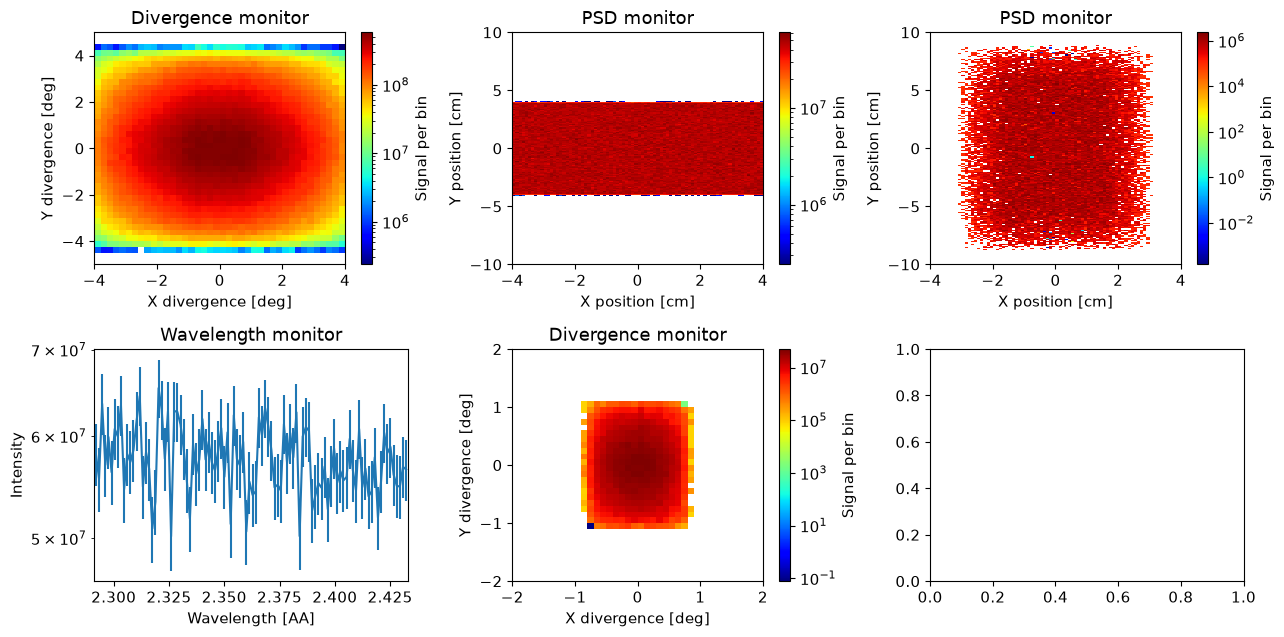

In [71]:
ms.make_sub_plot(data, log=True)

In [72]:
instrument.show_instrument(backend="pythreejs")

/tmp/ipykernel_34340/3604105874.py:1: UserWarning: The 'pythreejs' backend requires the optional module(s) pythreejs. Falling back to the 'webgl-classic' backend.
  instrument.show_instrument(backend="pythreejs")


McdisplayError: Could not start mcdisplay: [Errno 2] No such file or directory: '/usr/share/mcstas/resources/bin/mcdisplay-webgl-classic'

In [ ]:
Intensity = []
wavelengths = []
all_data = []
for i in range(50):
    wl = 0.5 + i * 0.1
    instrument.set_parameters(wavelength=wl, delta_wavelength=0.01)
    instrument.settings(ncount=2E6)
    data = instrument.backengine()
    all_data.append(data)

print("Scan complete!")
 


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_281"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
ki: 2.660000 A-1
kf: 2.044467 A-1
dE: 6.000000 meV
Lam: 2.362100 A
dLam: 0.070863 A
mth: -20.611333 deg
mtt: -41.222665 deg
sth: 25.300000 deg
stt: 50.600000 deg
ath: -27.258920 deg
att: -54.517839 d

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
print(all_data)

[[
McStasData: DIV type: 2D  I:885243000.0 E:834014.0 N:1164400.0, 
McStasData: PSD_1 type: 2D  I:908539000.0 E:844844.0 N:1195250.0, 
McStasData: PSD type: 2D  I:0.0 E:0.0 N:0.0, 
McStasData: DIV1 type: 2D  I:0.0 E:0.0 N:0.0], [
McStasData: DIV type: 2D  I:8682520000.0 E:8079630.0 N:1164580.0, 
McStasData: PSD_1 type: 2D  I:8909040000.0 E:8183610.0 N:1195180.0, 
McStasData: PSD type: 2D  I:0.0 E:0.0 N:0.0, 
McStasData: DIV1 type: 2D  I:0.0 E:0.0 N:0.0], [
McStasData: DIV type: 2D  I:27801600000.0 E:25799900.0 N:1163830.0, 
McStasData: PSD_1 type: 2D  I:28527500000.0 E:26132200.0 N:1194430.0, 
McStasData: PSD type: 2D  I:0.0 E:0.0 N:0.0, 
McStasData: DIV1 type: 2D  I:0.0 E:0.0 N:0.0], [
McStasData: DIV type: 2D  I:51060800000.0 E:47314200.0 N:1165380.0, 
McStasData: PSD_1 type: 2D  I:52396000000.0 E:47924300.0 N:1196080.0, 
McStasData: PSD type: 2D  I:0.0 E:0.0 N:0.0, 
McStasData: DIV1 type: 2D  I:0.0 E:0.0 N:0.0], [
McStasData: DIV type: 2D  I:70363700000.0 E:65170600.0 N:1165940.0, 


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0, 2.1, 2.2, 2.3, 2.4000000000000004, 2.5, 2.6, 2.7, 2.8000000000000003, 2.9000000000000004, 3.0, 3.1, 3.2, 3.3000000000000003, 3.4000000000000004, 3.5, 3.6, 3.7, 3.8000000000000003, 3.9000000000000004, 4.0, 4.1, 4.2, 4.300000000000001, 4.4, 4.5, 4.6000000000000005, 4.7, 4.8, 4.9, 5.0, 5.1000000000000005, 5.2, 5.300000000000001, 5.4]


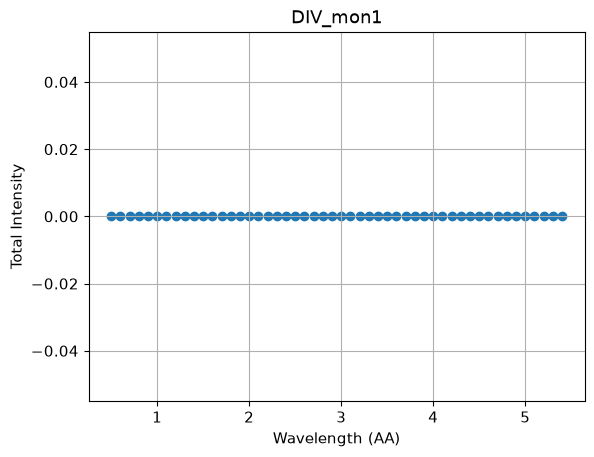

In [ ]:

DIV_mon1= []
wavelengths = []
for i in range(50):
    DIV_det_step= ms.name_search("DIV1", all_data[i])
    DIV_mon1.append(DIV_det_step.metadata.total_I)
    wavelengths.append(0.5 + i * 0.1)
print(DIV_mon1)
print(wavelengths)

plt.scatter(wavelengths, DIV_mon1)
plt.title("DIV_mon1")
plt.xlabel("Wavelength (AA)")
plt.ylabel("Total Intensity")
plt.grid()

In [ ]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_273"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
ki: 2.660000 A-1
kf: 2.044467 A-1
dE: 6.000000 meV
Lam: 2.362100 A
dLam: 0.070863 A
mth: -20.611333 deg
mtt: -41.222665 deg
sth: 25.300000 deg
stt: 50.600000 deg
ath: -27.258920 deg
att: -54.517839 d

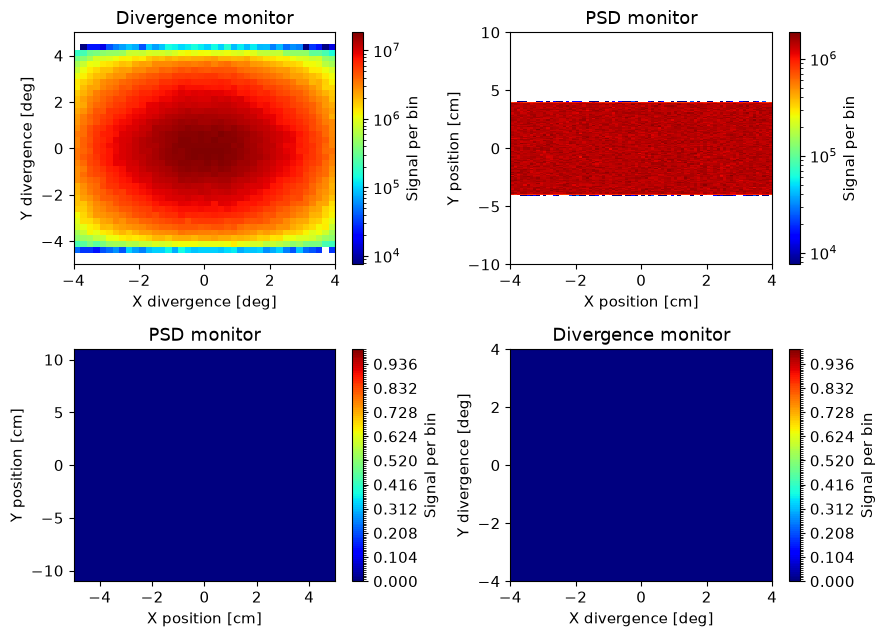

In [ ]:
ms.make_sub_plot(data, log=True)

In [ ]:
Intensity = []
Errors=[]
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 prim_shut_pos = 1.0
 sapphire = 1.0
 ca1 = 0.0
 ca2 = 0.0
 ca3 = 0.0
 ca4 = 0.0
 ms1 = 0.04
 lms = 2.1
 lsa = 1.05
 lad = 0.95
 ki = 2.66
 kf = 0.0
 dE = 6.0
 Q = 0.0
 scatsense_mono = -1.0
 scatsense_sample = 1.0
 scatsense_ana = -1.0
 mth = 37.166
 mtt = -74.332
 mtx = 0.0
 mty = 0.0
 mgy = 0.0
 mfh = 0.0
 mfv = 0.0
 sth = 25.3
 stt = 50.6
 stx = 0.0
 sty = 0.0
 stz = 0.0
 sgx = 0.0
 sgy = 0.0
 ss1_width = 0.04
 ss1_height = 0.08
 ss2_width = 0.04
 ss2_height = 0.08
 ath = -37.166
 att = -74.332
 atx = 0.0
 aty = 0.0
 agy = 0.0
 afh = 0.0
 afv = 0.0
 wavelength = 5.4
 delta_wavelength = 0.01



In [ ]:
print(Intensity)
print(Errors)

[0.0]
[0.0]


In [ ]:
NL_SR2_1.l=0.605
print(NL_SR2_1)

COMPONENT NL_SR2_1 = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.098, // [m]
  w2 = 0.105, // [m]
  h2 = 0.118, // [m]
  l = 0.605, // [m]
  R0 = 0.995, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 4.38, // [AA]
  W = 0.0009, // [AA-1]
  nslit = 1, // [1]
  mleft = 1.0, // [1]
  mright = 1.0, // [1]
  mtop = 1.0, // [1]
  mbottom = 1.0 // [1]
)
AT (0, 0, 1.18108) RELATIVE source


In [ ]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_274"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
ki: 2.660000 A-1
kf: 2.044467 A-1
dE: 6.000000 meV
Lam: 2.362100 A
dLam: 0.070863 A
mth: -20.611333 deg
mtt: -41.222665 deg
sth: 25.300000 deg
stt: 50.600000 deg
ath: -27.258920 deg
att: -54.517839 d

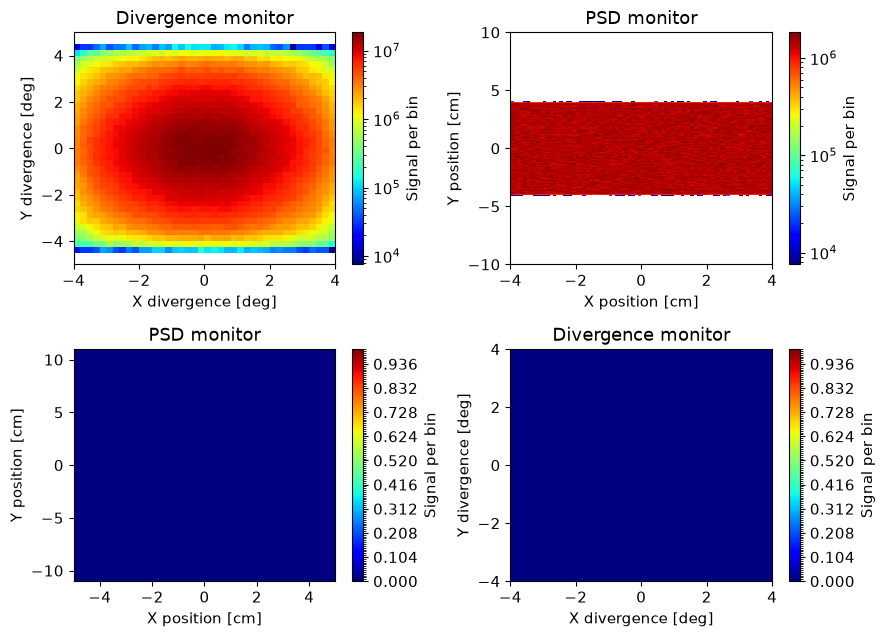

In [ ]:
ms.make_sub_plot(data, log=True)

In [ ]:
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 prim_shut_pos = 1.0
 sapphire = 1.0
 ca1 = 0.0
 ca2 = 0.0
 ca3 = 0.0
 ca4 = 0.0
 ms1 = 0.04
 lms = 2.1
 lsa = 1.05
 lad = 0.95
 ki = 2.66
 kf = 0.0
 dE = 6.0
 Q = 0.0
 scatsense_mono = -1.0
 scatsense_sample = 1.0
 scatsense_ana = -1.0
 mth = 37.166
 mtt = -74.332
 mtx = 0.0
 mty = 0.0
 mgy = 0.0
 mfh = 0.0
 mfv = 0.0
 sth = 25.3
 stt = 50.6
 stx = 0.0
 sty = 0.0
 stz = 0.0
 sgx = 0.0
 sgy = 0.0
 ss1_width = 0.04
 ss1_height = 0.08
 ss2_width = 0.04
 ss2_height = 0.08
 ath = -37.166
 att = -74.332
 atx = 0.0
 aty = 0.0
 agy = 0.0
 afh = 0.0
 afv = 0.0
 wavelength = 5.4
 delta_wavelength = 0.01



In [ ]:
print(Intensity)
print(Errors)

[0.0, 0.0]
[0.0, 0.0]


In [ ]:
NL_SR2_1.l=1.00

In [ ]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_275"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
ki: 2.660000 A-1
kf: 2.044467 A-1
dE: 6.000000 meV
Lam: 2.362100 A
dLam: 0.070863 A
mth: -20.611333 deg
mtt: -41.222665 deg
sth: 25.300000 deg
stt: 50.600000 deg
ath: -27.258920 deg
att: -54.517839 d

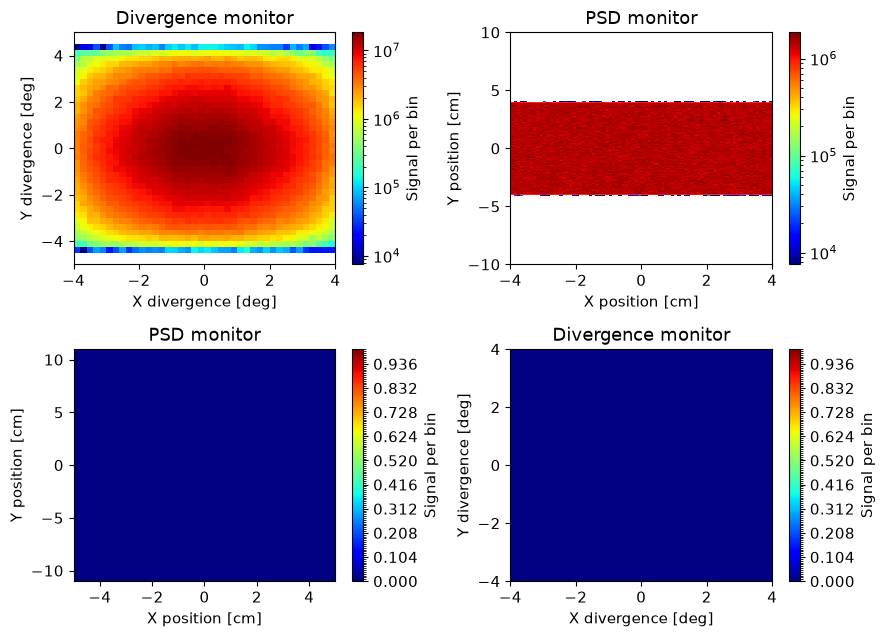

In [ ]:
ms.make_sub_plot(data, log=True)

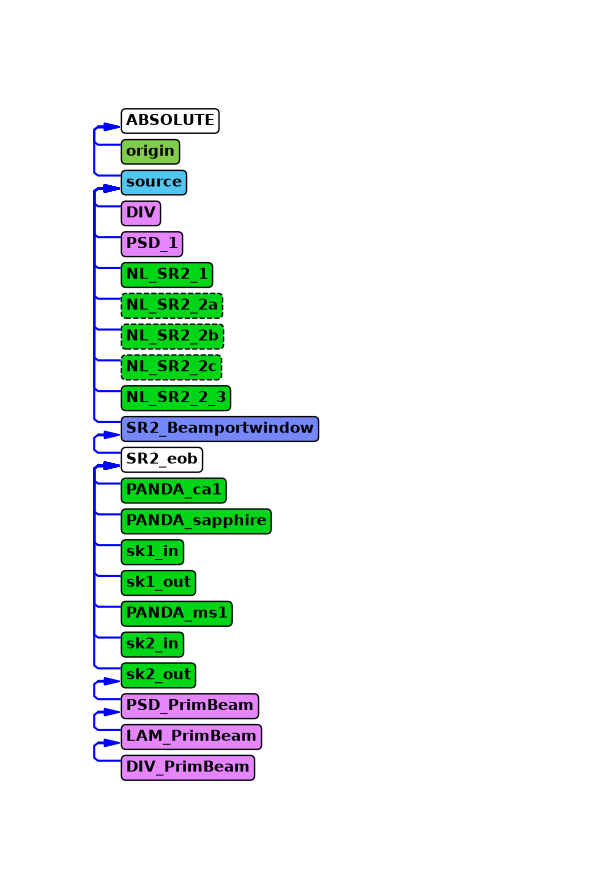

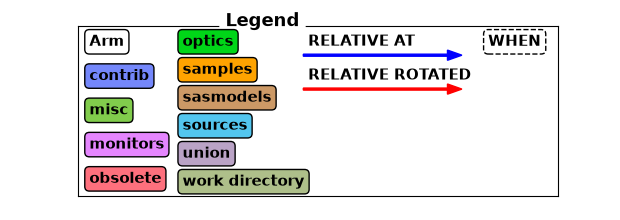

In [ ]:
instrument.show_diagram()

In [ ]:
pip install ply

Note: you may need to restart the kernel to use updated packages.


In [ ]:
instrument.show_instrument(format="webgl")

Starting mcdisplay-webgl (Vite dev server)...
A browser tab will open with the visualization.
Press the Stop button in the notebook toolbar to return here.


/tmp/ipykernel_3288/3658310673.py:1: DeprecationWarning: The 'format' parameter is deprecated, use 'backend' instead.
  instrument.show_instrument(format="webgl")


KeyboardInterrupt: 

In [ ]:
http://localhost:8000/index.html

SyntaxError: invalid syntax (2132679370.py, line 1)

In [ ]:
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)
print(Intensity)
print(Errors)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 wavelength = 0.7
 delta_wavelength = 0.01

[0.00310444, 0.00375123, 0.00340608]
[4.04198e-06, 4.44315e-06, 4.2338e-06]


In [ ]:
import matplotlib.pyplot as plt


/tmp/ipykernel_571/3419636049.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


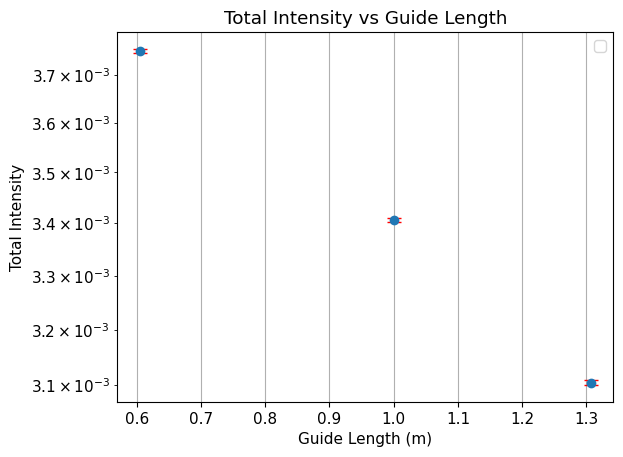

In [ ]:


NL_SR2_1_lengths = np.array([1.307, 0.605, 1.00])


plt.errorbar(NL_SR2_1_lengths, Intensity, yerr=Errors, fmt='o', ecolor='red', capsize=5, zorder=4)
plt.xlabel('Guide Length (m)')
plt.grid()
plt.ylabel('Total Intensity')
plt.title('Total Intensity vs Guide Length')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x7e59a6bb8180>, '_BaseCalculator__output_keys': ['NSM_instrument_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
wavelength                          0.7                             Wavelength in AA   
delta_wavelength                    0.01                            delta_Wavelength in AA   
, '_BaseCalculator__output': <libpyvinyl.BaseData.DataCollection object at 0x7e59a6655eb0>, 'author': 'Python McStas Instrument Generator', 'origin': 'ESS DMSC', '_run_settings': {'executable_path': '/usr/bin', 'package_path': '/usr/share/mcstas/resources', 'run_path': '.', 'e

In [ ]:
NL_SR2_2a = instrument.add_component("NL_SR2_2a", "Guide_gravity")


In [ ]:
NL_SR2_2a.show_parameters()
NL_SR2_2a.set_AT([0, 0, 2.540], RELATIVE=source)
NL_SR2_2a.set_parameters(w1=0.106, h1=0.119,
                         w2=0.106, h2=0.134,
                         l=0.997, R0=0.99,
                         Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=3.0, mright=3.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [ ]:
NL_SR2_2_3 = instrument.add_component("NL_SR2_2_3", "Guide_gravity")


In [ ]:
NL_SR2_2_3.show_parameters()
NL_SR2_2_3.set_AT([0, 0, 3.546], RELATIVE=source)
NL_SR2_2_3.set_parameters(w1=0.107, h1=0.135,
                          w2=0.107, h2=0.138,
                          l=0.180, R0=0.99,
                          Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=2.0, mright=2.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [ ]:
SR2_Beamportwindow= instrument.add_component("SR2_Beamportwindow", "Al_window")


In [ ]:
SR2_Beamportwindow.show_parameters()
SR2_Beamportwindow.set_AT([0, 0, 3.81], RELATIVE=source)
SR2_Beamportwindow.set_parameters(thickness=0.003)

 ___ Help Al_window _________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
thickness = 0.001 [m] // Al Window thickness
-------------------------------------------------------------------------------------


In [ ]:
SR2_eob= instrument.add_component("SR2_eob", "Arm")

In [ ]:

SR2_eob.set_AT([0,0,0.0031], RELATIVE= 'SR2_Beamportwindow')
SR2_eob.set_ROTATED([0,0,0], RELATIVE= 'SR2_Beamportwindow')

In [ ]:
PANDA_ca1= instrument.add_component("PANDA_ca1", "Collimator_linear")

In [ ]:
PANDA_ca1.show_parameters()
PANDA_ca1.set_parameters(xwidth=0.108, yheight=0.160, divergence=80, length=0.50, transmission=1)
PANDA_ca1.set_AT([0,0,0.1000], RELATIVE= 'SR2_eob')

 ___ Help Collimator_linear _________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = -0.02 [m] // Lower x bound on slits
xmax = 0.02 [m] // Upper x bound on slits
ymin = -0.05 [m] // Lower y bound on slits
ymax = 0.05 [m] // Upper y bound on slits
xwidth = 0.0 [m] // Width of slits
yheight = 0.0 [m] // Height of slits
length = 0.3 [m] // Distance between input and output slits
divergence = 40.0 [minutes of arc] // Divergence horizontal angle (calculated 
                                      as atan(d/length), where d is the blade 
                                      spacing) 
transmission = 1.0 [1] // Transmission of Soller (0<=t<=1)
divergenceV = 0.0 [minutes of arc] // Divergence vertical angle
-------------------------------------------------------------------------------------


In [ ]:
PANDA_sapphire = instrument.add_component("PANDA_sapphire", "Filter_gen")
PANDA_sapphire.set_parameters(filename = "Al2O3_sapphire.trm", thickness = 0.86)
PANDA_sapphire.set_AT([0,0,0.9000], RELATIVE= 'SR2_eob')

In [ ]:
data = instrument.backengine()

---- Found 2 places in McStas output with keyword 'error'. 

./NSM_instrument.c:10625:6: error: ‘Al2O3_sapphire’ undeclared (first use in this function)
10625 |   if(Al2O3_sapphire . trm && strlen(Al2O3_sapphire . trm))
      |      ^~~~~~~~~~~~~~
./NSM_instrument.c:10625:6: note: each undeclared identifier is reported only once for each function it appears in
INFO: call to gcc failed with Command 'gcc -o ./NSM_instrument.out ./NSM_instrument.c -lm -fno-PIC -fPIE -flto -O3 -mtune=native -march=native -fno-math-errno -ftree-vectorize -g -DNDEBUG -D_POSIX_SOURCE -std=c99 -lm' returned non-zero exit status 1.
----------------------------------------------------------------------
ERROR: Compilation failed for ./NSM_instrument.c using compiler gcc

----------------------------------------------------------------------

INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_247"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed compo

/home/sierra_manrique/miniforge3/lib/python3.13/site-packages/mcstasscript/helper/managed_mcrun.py:302: UserWarning: Simulation did not create data folder, most likely failed.
  warnings.warn("Simulation did not create data folder, most likely failed.")
/home/sierra_manrique/miniforge3/lib/python3.13/site-packages/mcstasscript/helper/managed_mcrun.py:332: UserWarning: No data available to load.
  warnings.warn("No data available to load.")
